# Augmented WDL/LWDL Timing Results

Timing-only visualization notebook for the augmented timing run. It reads `timing_table.csv` and, when present, `loss_history_all.csv` from a single run directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "experiments" / "timed_comparison").exists() and (path / "SAE.py").exists():
            return path
        nested = path / "wdl_repo"
        if (nested / "experiments" / "timed_comparison").exists() and (nested / "SAE.py").exists():
            return nested
    raise RuntimeError("Could not find repo root")


REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / "experiments" / "results"
DEFAULT_RUN_NAME = "timing_experiment_20260810_210236"
RUN_DIR = RESULTS_DIR / DEFAULT_RUN_NAME

if not (RUN_DIR / "timing_table.csv").exists():
    candidates = sorted(
        [p for p in RESULTS_DIR.glob("timing_experiment_*") if (p / "timing_table.csv").exists()],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(f"No timing_experiment_* runs with timing_table.csv under {RESULTS_DIR}")
    RUN_DIR = candidates[-1]

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"RUN_DIR   = {RUN_DIR}")

REPO_ROOT = REPO_ROOT
RUN_DIR   = REPO_ROOT/experiments/results/timing_experiment_20260810_210236


In [2]:
df = pd.read_csv(RUN_DIR / "timing_table.csv")

segment_cols = [
    "segment_forward_seconds",
    "segment_dictionary_grad_seconds",
    "segment_weights_grad_seconds",
    "segment_other_seconds",
]
expected_cols = {
    "experiment", "sample_size", "method", "variant", "embedding_seconds",
    "train_seconds", "clock_time_seconds", "mean_w2_squared", *segment_cols,
}
missing = sorted(expected_cols - set(df.columns))
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

sort_cols = ["experiment", "sample_size", "method", "gamma"]
df = df.sort_values(sort_cols, na_position="first").reset_index(drop=True)

display(df)
print(f"Rows: {len(df)}")

,experiment,sample_size,method,variant,epsilon,gamma,sinkhorn_iters,embedding_seconds,train_seconds,clock_time_seconds,epochs_completed,iterations_completed,termination_reason,mean_w2_squared,embedded_recon_loss,eval_status,eval_warning,numerical_error,segment_forward_seconds,segment_dictionary_grad_seconds,segment_weights_grad_seconds,segment_total_seconds,segment_other_seconds,segment_calls,model_state_path,history_path,artifact
0,mnist,100,ebcm,entropic_displacement,0.025,NaN,NaN,3.041211,1000.167686,1003.208897,50978.0,50978,max_elapsed_seconds,0.002578,0.000259,ok,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,experiments/results/timing_experiment_20260810_210236/mnist/n100/ebcm_eps0p025_history...,experiments/results/timing_experiment_20260810_210236/_cache/mnist/embeddings/digits0-...
1,mnist,100,heitz,wasserstein_dictionary_learning,NaN,0.5,5.0,0.000000,1018.337191,1018.337191,NaN,101,max_elapsed_seconds,0.012188,NaN,ok,NaN,False,361.359246,326.523148,305.978757,993.861151,24.476040,19700.0,NaN,experiments/results/timing_experiment_20260810_210236/mnist/n100/heitz_gamma0p5_sink5/...,experiments/results/timing_experiment_20260810_210236/mnist/n100/heitz_gamma0p5_sink5
2,mnist,100,heitz,wasserstein_dictionary_learning,NaN,2.0,5.0,0.000000,1009.255706,1009.255706,NaN,101,max_elapsed_seconds,0.010059,NaN,ok,NaN,False,358.169691,323.465397,303.311771,984.946859,24.308847,19500.0,NaN,experiments/results/timing_experiment_20260810_210236/mnist/n100/heitz_gamma2_sink5/hi...,experiments/results/timing_experiment_20260810_210236/mnist/n100/heitz_gamma2_sink5
3,mnist,1000,ebcm,entropic_displacement,0.025,NaN,NaN,31.505270,1000.217903,1031.723173,12965.0,51860,max_elapsed_seconds,0.002673,0.000320,ok,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,experiments/results/timing_experiment_20260810_210236/mnist/n1000/ebcm_eps0p025_histor...,experiments/results/timing_experiment_20260810_210236/_cache/mnist/embeddings/digits0-...
4,mnist,1000,heitz,wasserstein_dictionary_learning,NaN,0.5,5.0,0.000000,1005.637960,1005.637960,NaN,10,max_elapsed_seconds,0.012844,NaN,ok,NaN,False,345.672209,329.593170,306.762862,982.028241,23.609719,19000.0,NaN,experiments/results/timing_experiment_20260810_210236/mnist/n1000/heitz_gamma0p5_sink5...,experiments/results/timing_experiment_20260810_210236/mnist/n1000/heitz_gamma0p5_sink5
5,mnist,1000,heitz,wasserstein_dictionary_learning,NaN,2.0,5.0,0.000000,1028.631623,1028.631623,NaN,11,max_elapsed_seconds,0.013064,NaN,ok,NaN,False,364.622883,330.630948,308.541913,1003.795744,24.835879,20000.0,NaN,experiments/results/timing_experiment_20260810_210236/mnist/n1000/heitz_gamma2_sink5/h...,experiments/results/timing_experiment_20260810_210236/mnist/n1000/heitz_gamma2_sink5
6,pavia1d,100,heitz,wasserstein_dictionary_learning,NaN,0.5,5.0,0.000000,1009.674803,1009.674803,NaN,117,max_elapsed_seconds,0.004563,NaN,ok,NaN,False,348.981198,339.040239,309.422360,997.443797,12.231006,38000.0,NaN,experiments/results/timing_experiment_20260810_210236/pavia1d/n100/heitz_gamma0p5_sink...,experiments/results/timing_experiment_20260810_210236/pavia1d/n100/heitz_gamma0p5_sink5
7,pavia1d,100,heitz,wasserstein_dictionary_learning,NaN,2.0,5.0,0.000000,1000.042507,1000.042507,NaN,84,max_elapsed_seconds,0.004911,NaN,ok,NaN,False,357.619257,329.113029,300.594187,987.326473,12.716034,38800.0,NaN,experiments/results/timing_experiment_20260810_210236/pavia1d/n100/heitz_gamma2_sink5/...,experiments/results/timing_experiment_20260810_210236/pavia1d/n100/heitz_gamma2_sink5
8,pavia1d,100,heitz,wasserstein_dictionary_learning,NaN,10.0,5.0,0.000000,1001.579259,1001.579259,NaN,151,max_elapsed_seconds,0.004999,NaN,ok,NaN,False,361.403209,328.069579,299.438608,988.911396,12.667863,39400.0,NaN,experiments/results/timing_experiment_20260810_210236/pavia1d/n100/heitz_gamma10_sink5...,experiments/results/timing_experiment_20260810_210236/pavia1d/n100/heitz_gamma10_sink5
9,pavia1d,100,transport_map,JumpReLU_monotone,NaN,NaN,NaN,0.048798,1000.014265,1000.063063,240438.0,

Rows: 13


## Timing Summary Table

In [3]:
summary_cols = [
    "experiment", "sample_size", "method", "gamma", "epsilon", "sinkhorn_iters",
    "embedding_seconds", "train_seconds", "clock_time_seconds",
    "iterations_completed", "epochs_completed", "termination_reason",
    "mean_w2_squared", "segment_total_seconds", "segment_other_seconds", "segment_calls",
]
summary = df[[c for c in summary_cols if c in df.columns]].copy()
for col in ["embedding_seconds", "train_seconds", "clock_time_seconds", "mean_w2_squared", "segment_total_seconds", "segment_other_seconds"]:
    if col in summary.columns:
        summary[col] = summary[col].round(6)
display(summary)

,experiment,sample_size,method,gamma,epsilon,sinkhorn_iters,embedding_seconds,train_seconds,clock_time_seconds,iterations_completed,epochs_completed,termination_reason,mean_w2_squared,segment_total_seconds,segment_other_seconds,segment_calls
0,mnist,100,ebcm,NaN,0.025,NaN,3.041211,1000.167686,1003.208897,50978,50978.0,max_elapsed_seconds,0.002578,NaN,NaN,NaN
1,mnist,100,heitz,0.5,NaN,5.0,0.000000,1018.337191,1018.337191,101,NaN,max_elapsed_seconds,0.012188,993.861151,24.476040,19700.0
2,mnist,100,heitz,2.0,NaN,5.0,0.000000,1009.255706,1009.255706,101,NaN,max_elapsed_seconds,0.010059,984.946859,24.308847,19500.0
3,mnist,1000,ebcm,NaN,0.025,NaN,31.505270,1000.217903,1031.723173,51860,12965.0,max_elapsed_seconds,0.002673,NaN,NaN,NaN
4,mnist,1000,heitz,0.5,NaN,5.0,0.000000,1005.637960,1005.637960,10,NaN,max_elapsed_seconds,0.012844,982.028241,23.609719,19000.0
5,mnist,1000,heitz,2.0,NaN,5.0,0.000000,1028.631623,1028.631623,11,NaN,max_elapsed_seconds,0.013064,1003.795744,24.835879,20000.0
6,pavia1d,100,heitz,0.5,NaN,5.0,0.000000,1009.674803,1009.674803,117,NaN,max_elapsed_seconds,0.004563,997.443797,12.231006,38000.0
7,pavia1d,100,heitz,2.0,NaN,5.0,0.000000,1000.042507,1000.042507,84,NaN,max_elapsed_seconds,0.004911,987.326473,12.716034,38800.0
8,pavia1d,100,heitz,10.0,NaN,5.0,0.000000,1001.579259,1001.579259,151,NaN,max_elapsed_seconds,0.004999,988.911396,12.667863,39400.0
9,pavia1d,100,transport_map,NaN,NaN,NaN,0.048798,1000.014265,1000.063063,240438,240438.0,max_elapsed_seconds,0.000050,NaN,NaN,NaN


## Wall-Clock Time By Method

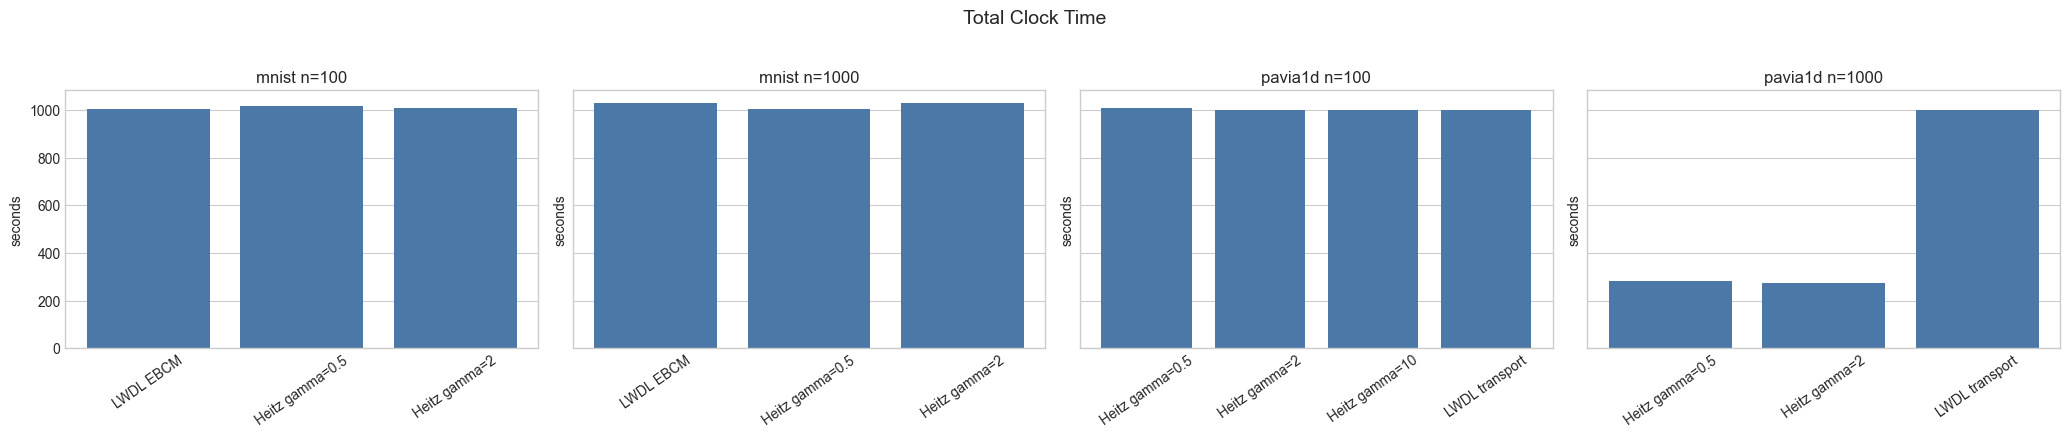

In [4]:
plot_df = df.copy()
plot_df["method_label"] = np.where(
    plot_df["method"].eq("heitz"),
    "Heitz gamma=" + plot_df["gamma"].map(lambda x: f"{x:g}" if pd.notna(x) else ""),
    np.where(plot_df["method"].eq("transport_map"), "LWDL transport", "LWDL EBCM"),
)
plot_df["case"] = plot_df["experiment"] + " n=" + plot_df["sample_size"].astype(str)

cases = list(plot_df["case"].drop_duplicates())
fig, axes = plt.subplots(1, len(cases), figsize=(5.2 * len(cases), 4.2), sharey=True)
if len(cases) == 1:
    axes = [axes]

for ax, case in zip(axes, cases):
    sub = plot_df[plot_df["case"] == case].copy()
    ax.bar(sub["method_label"], sub["clock_time_seconds"], color="#4c78a8")
    ax.set_title(case)
    ax.set_ylabel("seconds")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="x", visible=False)

fig.suptitle("Total Clock Time", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

## Heitz Algorithm Segment Breakdown

The segment columns are cumulative C++ timers inside the Heitz `SinkhornGrads` routine: forward Sinkhorn/barycenter, dictionary-gradient backward pass, weights-gradient backward pass, and residual other time.

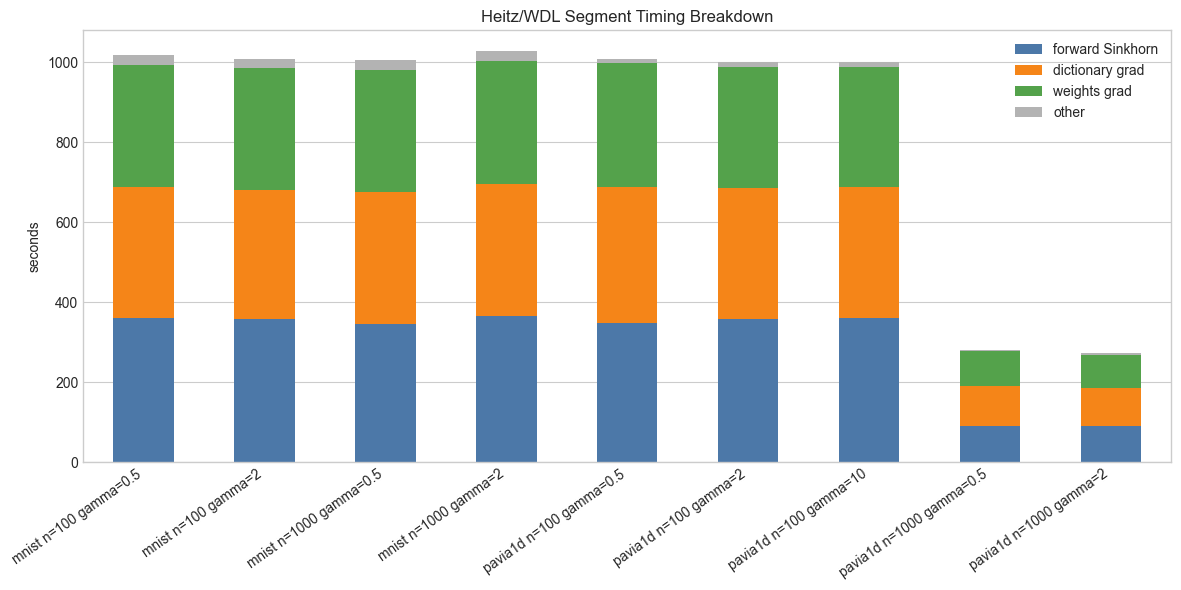

In [5]:
heitz = df[df["method"].eq("heitz")].copy()
heitz["label"] = (
    heitz["experiment"]
    + " n=" + heitz["sample_size"].astype(str)
    + " gamma=" + heitz["gamma"].map(lambda x: f"{x:g}")
)

segment_labels = {
    "segment_forward_seconds": "forward Sinkhorn",
    "segment_dictionary_grad_seconds": "dictionary grad",
    "segment_weights_grad_seconds": "weights grad",
    "segment_other_seconds": "other",
}

ax = heitz.set_index("label")[segment_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#4c78a8", "#f58518", "#54a24b", "#b3b3b3"],
)
ax.set_title("Heitz/WDL Segment Timing Breakdown")
ax.set_xlabel("")
ax.set_ylabel("seconds")
ax.legend([segment_labels[c] for c in segment_cols], loc="upper right")
ax.grid(axis="x", visible=False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Heitz Segment Percentages

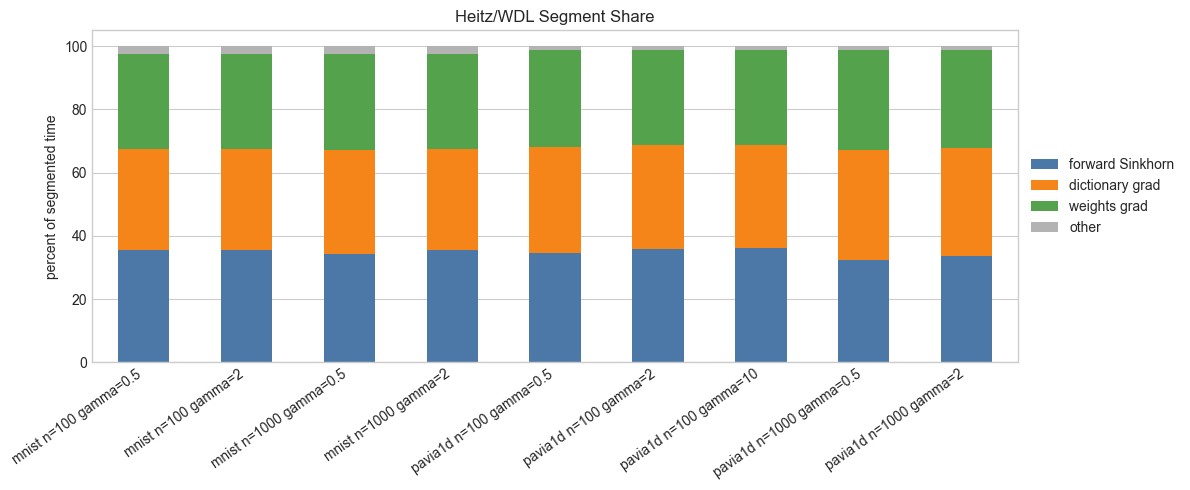

,label,segment_forward_seconds,segment_dictionary_grad_seconds,segment_weights_grad_seconds,segment_other_seconds
1,mnist n=100 gamma=0.5,35.49,32.06,30.05,2.40
2,mnist n=100 gamma=2,35.49,32.05,30.05,2.41
4,mnist n=1000 gamma=0.5,34.37,32.77,30.50,2.35
5,mnist n=1000 gamma=2,35.45,32.14,30.00,2.41
6,pavia1d n=100 gamma=0.5,34.56,33.58,30.65,1.21
7,pavia1d n=100 gamma=2,35.76,32.91,30.06,1.27
8,pavia1d n=100 gamma=10,36.08,32.76,29.90,1.26
10,pavia1d n=1000 gamma=0.5,32.51,34.81,31.53,1.15
11,pavia1d n=1000 gamma=2,33.62,34.18,31.02,1.18


In [6]:
pct = heitz[["label", *segment_cols]].copy()
pct_total = pct[segment_cols].sum(axis=1)
for col in segment_cols:
    pct[col] = pct[col] / pct_total * 100

ax = pct.set_index("label")[segment_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#4c78a8", "#f58518", "#54a24b", "#b3b3b3"],
)
ax.set_title("Heitz/WDL Segment Share")
ax.set_xlabel("")
ax.set_ylabel("percent of segmented time")
ax.legend([segment_labels[c] for c in segment_cols], loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(axis="x", visible=False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(pct.round(2))

## Timing Versus Reconstruction Error

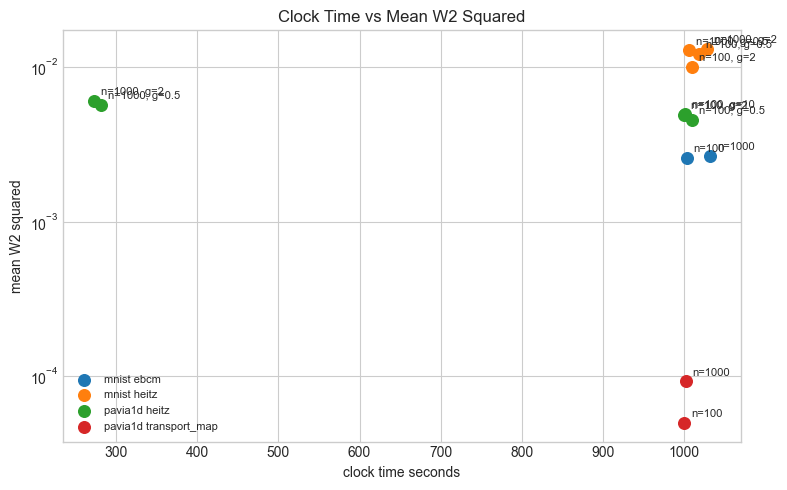

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for (experiment, method), group in df.dropna(subset=["mean_w2_squared"]).groupby(["experiment", "method"]):
    label = f"{experiment} {method}"
    ax.scatter(group["clock_time_seconds"], group["mean_w2_squared"], s=70, label=label)
    for _, row in group.iterrows():
        suffix = f"n={int(row['sample_size'])}"
        if pd.notna(row.get("gamma")):
            suffix += f", g={row['gamma']:g}"
        ax.annotate(suffix, (row["clock_time_seconds"], row["mean_w2_squared"]), xytext=(5, 4), textcoords="offset points", fontsize=8)

ax.set_title("Clock Time vs Mean W2 Squared")
ax.set_xlabel("clock time seconds")
ax.set_ylabel("mean W2 squared")
ax.set_yscale("log")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Optional: Loss Curves

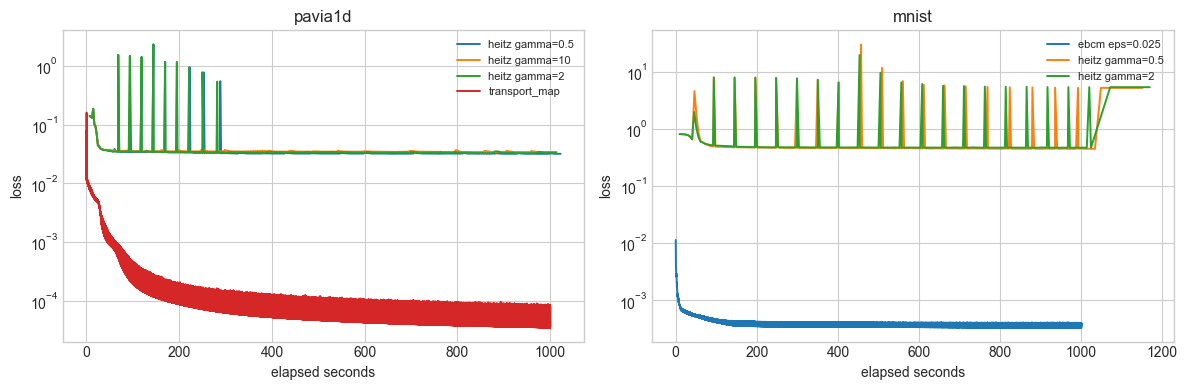

In [8]:
loss_path = RUN_DIR / "loss_history_all.csv"
if not loss_path.exists():
    print(f"No loss history found: {loss_path}")
else:
    hist = pd.read_csv(loss_path)
    hist = hist.dropna(subset=["elapsed_seconds", "loss"]).copy()
    hist["label"] = hist["method"].astype(str)
    if "gamma" in hist.columns:
        hist["label"] = np.where(hist["gamma"].notna(), hist["label"] + " gamma=" + hist["gamma"].map(lambda x: f"{x:g}" if pd.notna(x) else ""), hist["label"])
    if "epsilon" in hist.columns:
        hist["label"] = np.where(hist["epsilon"].notna(), hist["label"] + " eps=" + hist["epsilon"].map(lambda x: f"{x:g}" if pd.notna(x) else ""), hist["label"])

    experiments = list(hist["experiment"].dropna().unique()) if "experiment" in hist.columns else ["all"]
    fig, axes = plt.subplots(1, len(experiments), figsize=(6 * len(experiments), 4), squeeze=False)
    for ax, experiment in zip(axes.flat, experiments):
        sub = hist[hist["experiment"].eq(experiment)] if "experiment" in hist.columns else hist
        for label, group in sub.groupby("label"):
            group = group.sort_values("elapsed_seconds")
            ax.plot(group["elapsed_seconds"], group["loss"], linewidth=1.4, label=label)
        ax.set_title(str(experiment))
        ax.set_xlabel("elapsed seconds")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Save Figures

In [9]:
out_dir = RUN_DIR / "timing_visualizations"
out_dir.mkdir(exist_ok=True)

# Recreate the two most useful figures as files.
ax = heitz.set_index("label")[segment_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#4c78a8", "#f58518", "#54a24b", "#b3b3b3"],
)
ax.set_title("Heitz/WDL Segment Timing Breakdown")
ax.set_xlabel("")
ax.set_ylabel("seconds")
ax.legend([segment_labels[c] for c in segment_cols], loc="upper right")
ax.grid(axis="x", visible=False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "heitz_segment_timing_breakdown.png", dpi=200)
plt.close()

ax = pct.set_index("label")[segment_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#4c78a8", "#f58518", "#54a24b", "#b3b3b3"],
)
ax.set_title("Heitz/WDL Segment Share")
ax.set_xlabel("")
ax.set_ylabel("percent of segmented time")
ax.legend([segment_labels[c] for c in segment_cols], loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(axis="x", visible=False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "heitz_segment_timing_percent.png", dpi=200)
plt.close()

print(f"Saved figures to {out_dir}")

Saved figures to REPO_ROOT/experiments/results/timing_experiment_20260810_210236/timing_visualizations
